# World Happiness Report Exploratory Data Analysis (2015–2019)

**Author:** Saleha A.  
**Dataset:** World Happiness Report (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, SQLite

An analysis of global happiness trends across 150+ countries, 
exploring how GDP, social support, freedom, and other factors 
drive national wellbeing, with a focused look at the UAE and Gulf region.

In [3]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 1. Data Loading & Cleaning

Five separate CSV files (2015–2019) were loaded, standardised, and 
combined into a single dataset. Column names varied across years and 
were renamed for consistency. One missing Corruption value was filled 
using the column median.

In [5]:
#File paths
files = {
    2015: "EDA_data/2015.csv",  #World happiness report 2015
    2016: "EDA_data/2016.csv",  #World happiness report 2016
    2017: "EDA_data/2017.csv",  #World happiness report 2017
    2018: "EDA_data/2018.csv",  #World happiness report 2018
    2019: "EDA_data/2019.csv"   #World happiness report 2019
}

#Function to clean data
def clean_data(df, year):
    #Add year column
    df["Year"] = year

    #Standardise column names across all datasets
    df = df.rename(columns={
        # 2015/2016
        "Country": "Country",
        "Happiness Score": "Happiness_Score",
        "Economy (GDP per Capita)": "GDP",
        "Family": "Social_Support",
        "Health (Life Expectancy)": "Life_Expectancy",
        "Freedom": "Freedom",
        "Generosity": "Generosity",
        "Trust (Government Corruption)": "Corruption",

        # 2017
        "Happiness.Score": "Happiness_Score",
        "Economy..GDP.per.Capita.": "GDP",
        "Health..Life.Expectancy.": "Life_Expectancy",
        "Trust..Government.Corruption.": "Corruption",

        # 2018/2019
        "Country or region": "Country",
        "Score": "Happiness_Score",
        "GDP per capita": "GDP",
        "Social support": "Social_Support",
        "Healthy life expectancy": "Life_Expectancy",
        "Freedom to make life choices": "Freedom",
        "Perceptions of corruption": "Corruption"
    })

    #Selecting required columns
    columns_needed = [
        "Country", "Year", "Happiness_Score", "GDP",
        "Social_Support", "Life_Expectancy",
        "Freedom", "Generosity", "Corruption"
    ]
    df = df[[col for col in columns_needed if col in df.columns]]
    return df

#load, clean, and store all datasets
dfs = []
for year, path in files.items():
    df = pd.read_csv(path)
    df_clean = clean_data(df, year)
    dfs.append(df_clean)

#Combine into one dataset
df = pd.concat(dfs, ignore_index=True)

#Sort values by Country and Year
df = df.sort_values(by=["Country", "Year"]).reset_index(drop=True)

#Preview
print(df.head())

       Country  Year  Happiness_Score       GDP  Social_Support  \
0  Afghanistan  2015            3.575  0.319820        0.302850   
1  Afghanistan  2016            3.360  0.382270        0.110370   
2  Afghanistan  2017            3.794  0.401477        0.581543   
3  Afghanistan  2018            3.632  0.332000        0.537000   
4  Afghanistan  2019            3.203  0.350000        0.517000   

   Life_Expectancy  Freedom  Generosity  Corruption  
0         0.303350  0.23414    0.365100    0.097190  
1         0.173440  0.16430    0.312680    0.071120  
2         0.180747  0.10618    0.311871    0.061158  
3         0.255000  0.08500    0.191000    0.036000  
4         0.361000  0.00000    0.158000    0.025000  


In [104]:
df.head()

,Country,Year,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
0,Afghanistan,2015,3.575,0.319820,0.302850,0.303350,0.23414,0.365100,0.097190
1,Afghanistan,2016,3.360,0.382270,0.110370,0.173440,0.16430,0.312680,0.071120
2,Afghanistan,2017,3.794,0.401477,0.581543,0.180747,0.10618,0.311871,0.061158
3,Afghanistan,2018,3.632,0.332000,0.537000,0.255000,0.08500,0.191000,0.036000
4,Afghanistan,2019,3.203,0.350000,0.517000,0.361000,0.00000,0.158000,0.025000


In [105]:
#Understanding the database

#Identifying number of rows and columns
print("Number of rows and columns: " + str(df.shape)+"\n") 

#the number of records in each column, type of data, whether any values are missing and how much memory the dataset uses. 
df.info()

#Statistical summary of the DataFrame (Transpose) showing values like count, mean, standard deviation, minimum and quartiles for each numerical column.
df.describe().T 

Number of rows and columns: (782, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          782 non-null    object 
 1   Year             782 non-null    int64  
 2   Happiness_Score  782 non-null    float64
 3   GDP              782 non-null    float64
 4   Social_Support   782 non-null    float64
 5   Life_Expectancy  782 non-null    float64
 6   Freedom          782 non-null    float64
 7   Generosity       782 non-null    float64
 8   Corruption       781 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 55.1+ KB


,count,mean,std,min,25%,50%,75%,max
Year,782.0,2016.993606,1.417364,2015.000,2016.000000,2017.000000,2018.000000,2019.000000
Happiness_Score,782.0,5.379018,1.127456,2.693,4.509750,5.322000,6.189500,7.769000
GDP,782.0,0.916047,0.407340,0.000,0.606500,0.982205,1.236187,2.096000
Social_Support,782.0,1.078392,0.329548,0.000,0.869363,1.124735,1.327250,1.644000
Life_Expectancy,782.0,0.612416,0.248309,0.000,0.440183,0.647310,0.808000,1.141000
Freedom,782.0,0.411091,0.152880,0.000,0.309768,0.431000,0.531000,0.724000
Generosity,782.0,0.218576,0.122321,0.000,0.130000,0.201982,0.278832,0.838075
Corruption,781.0,0.125436,0.105816,0.000,0.054000,0.091000,0.156030,0.551910


In [106]:
#Changing data type
df["Year"] = df["Year"].astype("str")

#Handling missing values
df["Corruption"] = df.groupby("Country")["Corruption"].transform(
    lambda x: x.interpolate().bfill().ffill()
)

In [107]:
df.head()

,Country,Year,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
0,Afghanistan,2015,3.575,0.319820,0.302850,0.303350,0.23414,0.365100,0.097190
1,Afghanistan,2016,3.360,0.382270,0.110370,0.173440,0.16430,0.312680,0.071120
2,Afghanistan,2017,3.794,0.401477,0.581543,0.180747,0.10618,0.311871,0.061158
3,Afghanistan,2018,3.632,0.332000,0.537000,0.255000,0.08500,0.191000,0.036000
4,Afghanistan,2019,3.203,0.350000,0.517000,0.361000,0.00000,0.158000,0.025000


## 2. Exploratory Analysis & Visualisation

The following charts explore happiness trends globally and within the 
Gulf region, and investigate which factors correlate most strongly 
with national happiness. SQL queries were used where relevant to extract and aggregate data, with results 
passed directly into Python for visualisation.ess.

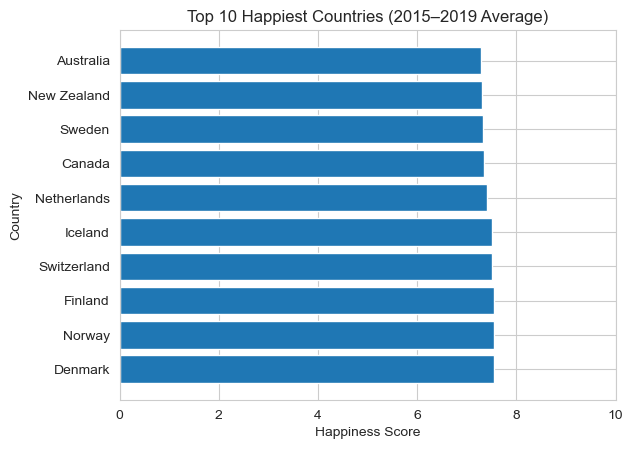

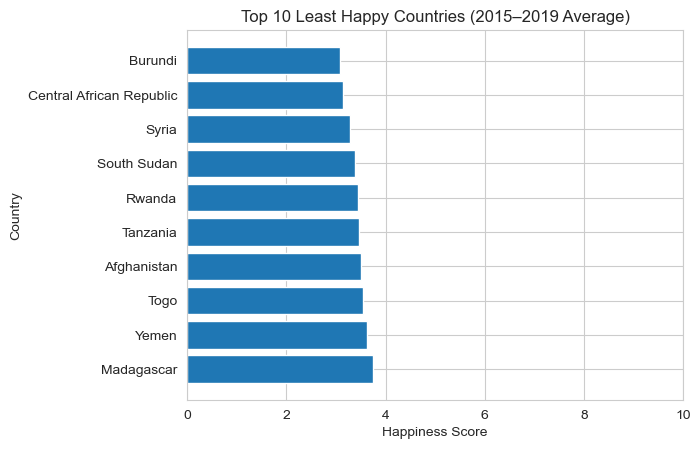

In [156]:
#What are the top 10 happiest and 10 least happiest countries?

import sqlite3

#Creating in-memory database
conn = sqlite3.connect(":memory:")

#loading dataframe into SQL table
df.to_sql("happiness", conn, index=False, if_exists="replace")

#Top 10 happiest countries
top10_query = """
SELECT Country, AVG(Happiness_Score) AS avg_score
FROM happiness
GROUP BY Country
ORDER BY avg_score DESC
LIMIT 10;
"""

top10 = pd.read_sql_query(top10_query, conn)
top10 = top10.sort_values("avg_score")

plt.figure()
plt.barh(top10["Country"], top10["avg_score"])
plt.title("Top 10 Happiest Countries (2015–2019 Average)")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.xlim(0, 10)
plt.gca().invert_yaxis()
plt.show()

#Bottom 10 happiest countries
bottom10_query = """
SELECT Country, AVG(Happiness_Score) AS avg_score
FROM happiness
GROUP BY Country
ORDER BY avg_score ASC
LIMIT 10;
"""

bottom10 = pd.read_sql_query(bottom10_query, conn)
bottom10 = bottom10.sort_values("avg_score")

plt.figure()
plt.barh(bottom10["Country"], bottom10["avg_score"])
plt.title("Top 10 Least Happy Countries (2015–2019 Average)")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.xlim(0, 10)
plt.gca().invert_yaxis()
plt.show()

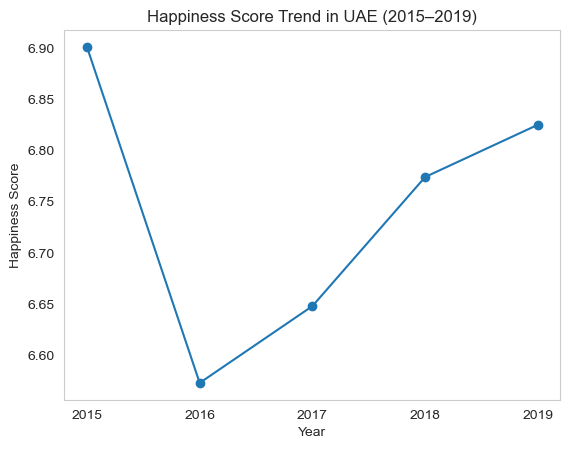

In [109]:
#How has the UAE's happiness score changed over 5 years?

#Filtering UAE data
uae_df = df[df["Country"] == "United Arab Emirates"]

#Sorting by Year
uae_df = uae_df.sort_values("Year")

#Plotting line graph
plt.figure()
plt.plot(uae_df["Year"], uae_df["Happiness_Score"], marker='o')

plt.title("Happiness Score Trend in UAE (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Happiness Score")

plt.grid()
plt.show()

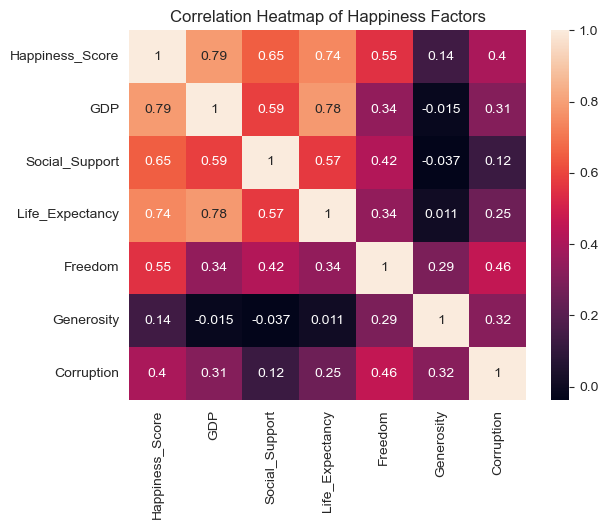

In [110]:
#What factors drive happiness most?

#Selecting relevant columns
corr_df = df[[
    "Happiness_Score", "GDP", "Social_Support",
    "Life_Expectancy", "Freedom", "Generosity", "Corruption"
]]

#Computing correlation
corr_matrix = corr_df.corr()

#Plotting heatmap
plt.figure()
sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Heatmap of Happiness Factors")
plt.show()

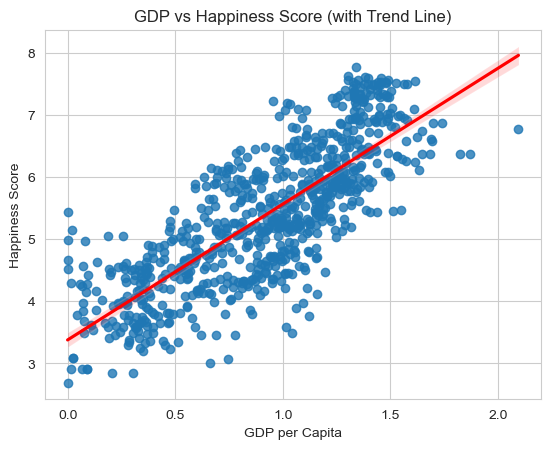

In [111]:
#GDP vs Happiness
sns.regplot(x="GDP", y="Happiness_Score", data=df, line_kws={"color":"red"})

plt.title("GDP vs Happiness Score (with Trend Line)")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")

plt.show()

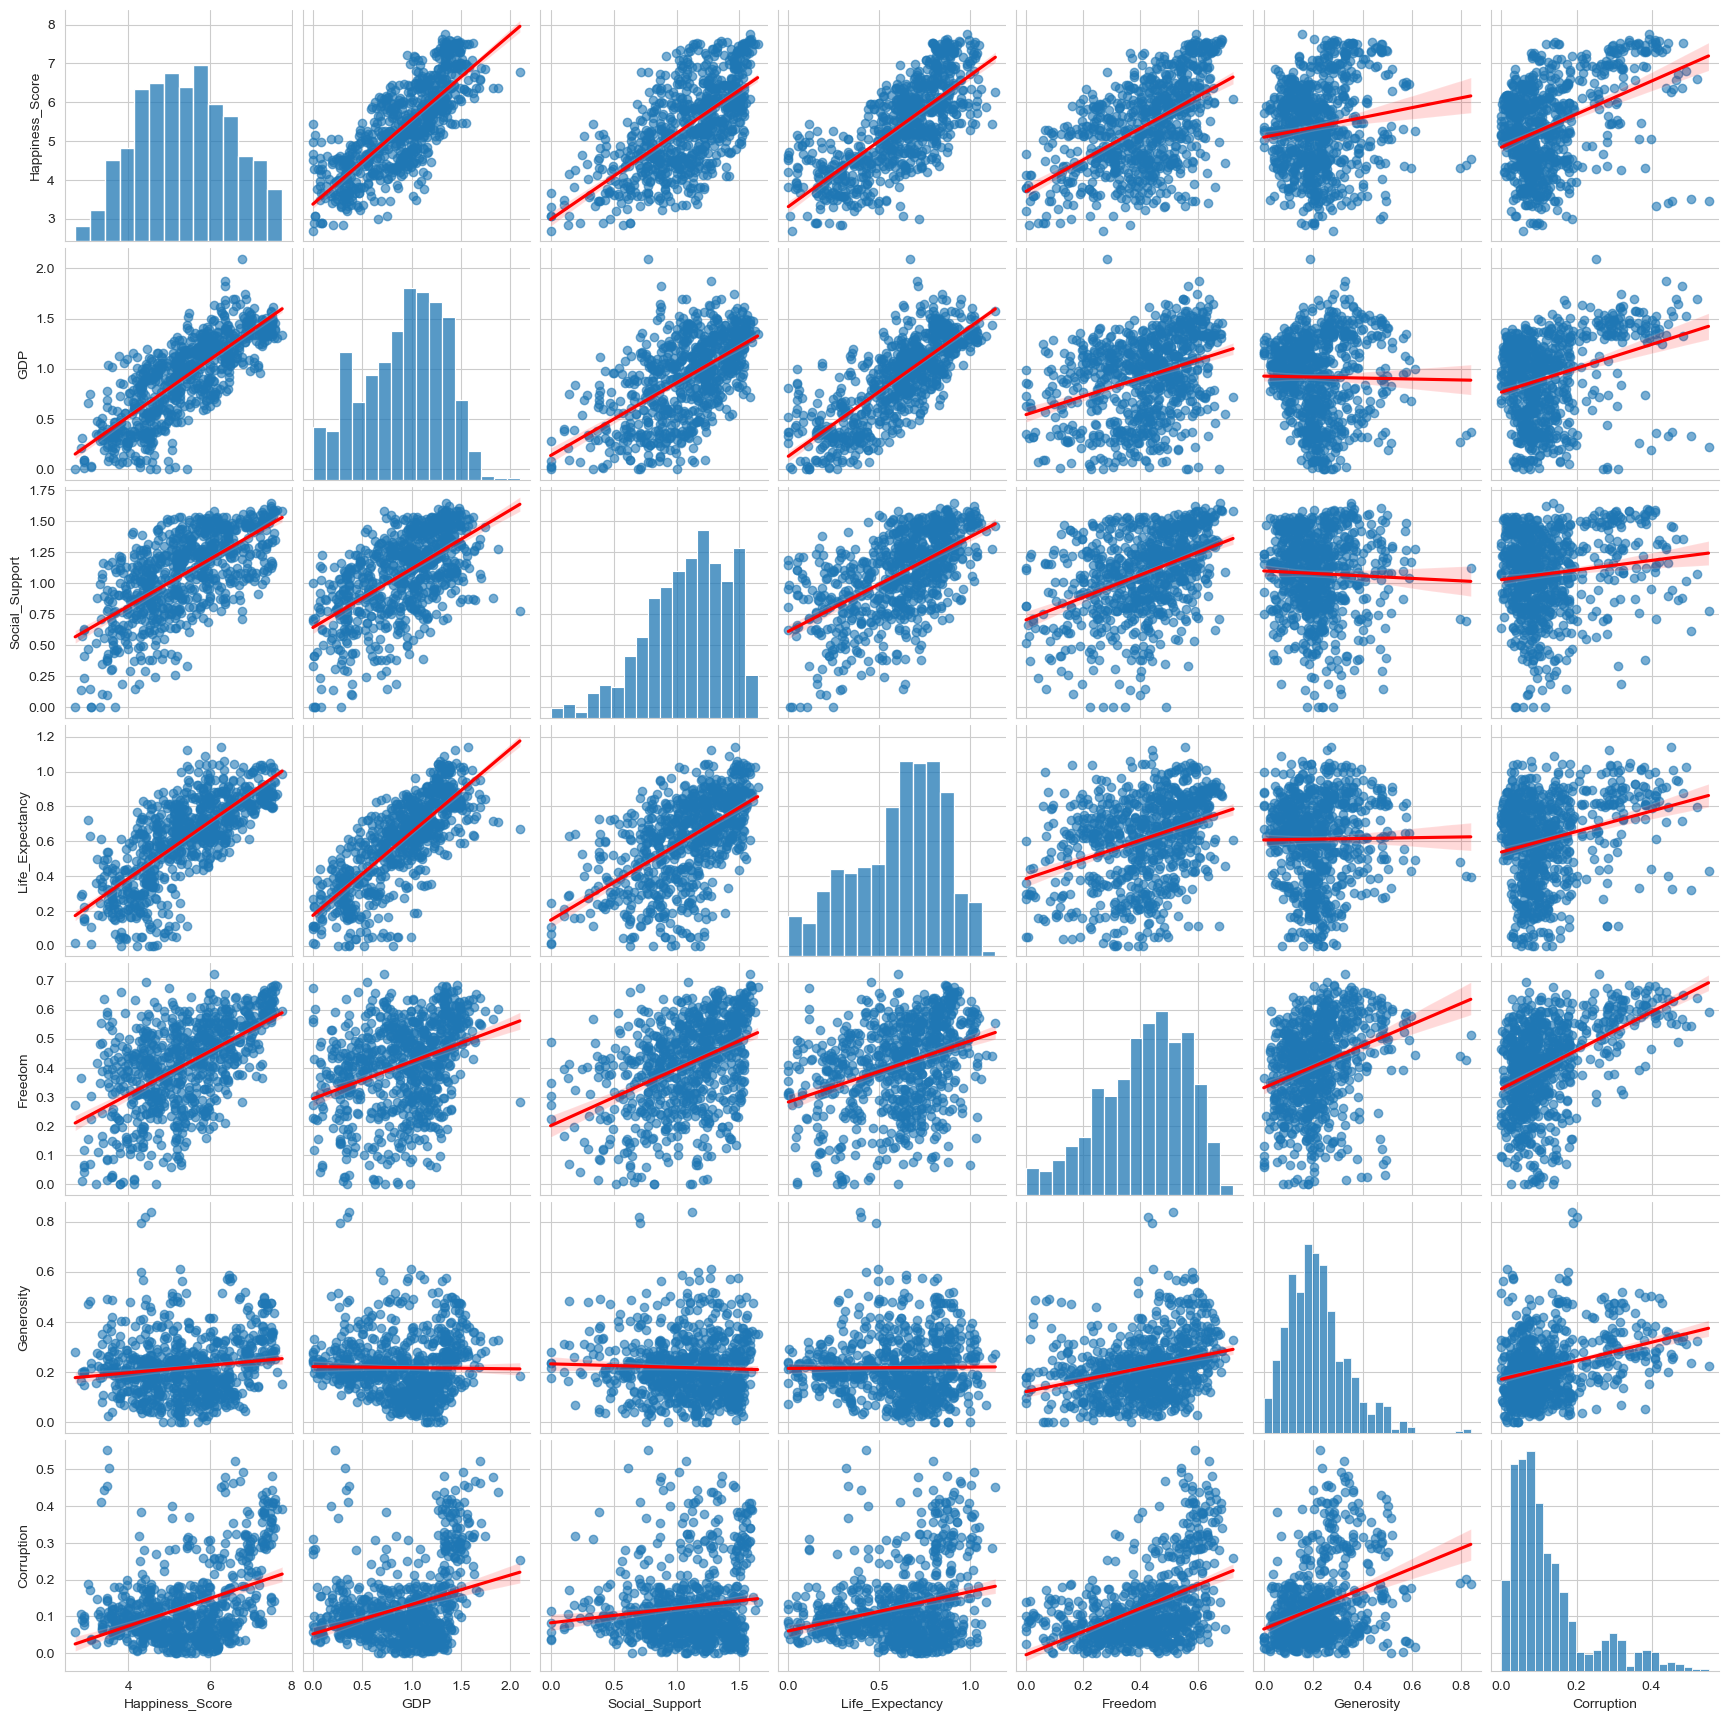

In [112]:
#Pair plot to show coreelation between factors

#Style for cleaner visuals
sns.set_style("whitegrid")

#Selecting relevant columns
pair_df = df[[
    "Happiness_Score", "GDP", "Social_Support",
    "Life_Expectancy", "Freedom", "Generosity", "Corruption"
]]

#Create pair plot
sns.pairplot(
    pair_df,
    kind="reg",
    plot_kws={
        "scatter_kws": {"alpha": 0.6},   # dots (default blue)
        "line_kws": {"color": "red"}     # regression line
    }
)

plt.show()

## 3. Export for Excel Dashboard

The cleaned dataset is exported to CSV for further visualisation in an interactive Excel dashboard.

In [7]:
#Exporting data to Excel
df.to_csv('happiness_clean.csv', index=False)

## Key Findings

1. **GDP is the strongest predictor of happiness (0.79)** — wealthier 
nations consistently score higher, but wealth alone doesn't tell the 
whole story.

2. **GDP, Life Expectancy, and Social Support form an interconnected 
cluster** — these three factors reinforce each other, suggesting 
happiness is driven by systems working together rather than any 
single factor.

3. **Generosity has almost no correlation with national happiness 
(0.14)** — the least intuitive finding; altruistic nations are not 
necessarily happier ones.

4. **Freedom is a moderate but consistent predictor (0.55)** — 
countries with greater personal freedom score meaningfully higher 
regardless of wealth level.

5. **Corruption's positive correlation (0.4) reflects reporting 
transparency** — wealthier, more open societies report corruption 
more visibly, creating a misleading positive relationship with 
happiness.

6. **The UAE experienced a notable happiness dip in 2016 (-0.32 
points) before recovering steadily through 2019** — this likely 
reflects the impact of the 2015–2016 Gulf oil price crisis on 
regional economic sentiment, demonstrating how macroeconomic shocks 
affect wellbeing even in diversified economies like the UAE.